# 01 - Smoke Exposure Pipeline

Document and validate the HMS smoke instrument construction. This notebook explains the hardest engineering step: mapping NOAA smoke plumes to school districts.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

## Instrument construction logic

For each district x year:
1. Load NOAA HMS daily smoke plume polygons
2. Test if district centroid falls inside a Medium or Heavy smoke plume
3. Count days with smoke exposure = `smoke_days`
4. `smoke_days` is the instrument for PM2.5 exposure

**Why this is a valid instrument:**
- Relevance: wildfire smoke drives PM2.5 at monitors near affected districts
- Exclusion: smoke from distant wildfires affects test scores only through air quality, not through local economic activity or school policy

## Load and inspect smoke instrument

In [2]:
smoke_path = DATA_DIR / "smoke_instrument_district_year.parquet"
if not smoke_path.exists():
    raise FileNotFoundError("Run src/exposure/smoke_instrument.py first")

smoke = pd.read_parquet(smoke_path)
print(f"Smoke instrument: {smoke.shape}")
print(smoke.describe().round(2))

Smoke instrument: (38240, 5)
            leaid      year  smoke_days  smoke_days_heavy  smoke_days_medium
count    38240.00  38240.00    38240.00          38240.00            38240.0
mean   2077280.82   2014.50       25.25              2.62                5.1
std    1883924.47      2.87       18.85              4.85                5.5
min     400001.00   2010.00        0.00              0.00                0.0
25%     602655.00   2012.00       10.00              0.00                1.0
50%     800263.50   2014.50       21.00              1.00                3.0
75%    3500179.25   2017.00       39.00              3.00                8.0
max    5900195.00   2019.00       99.00             52.00               27.0


## Smoke days by year (national trends)

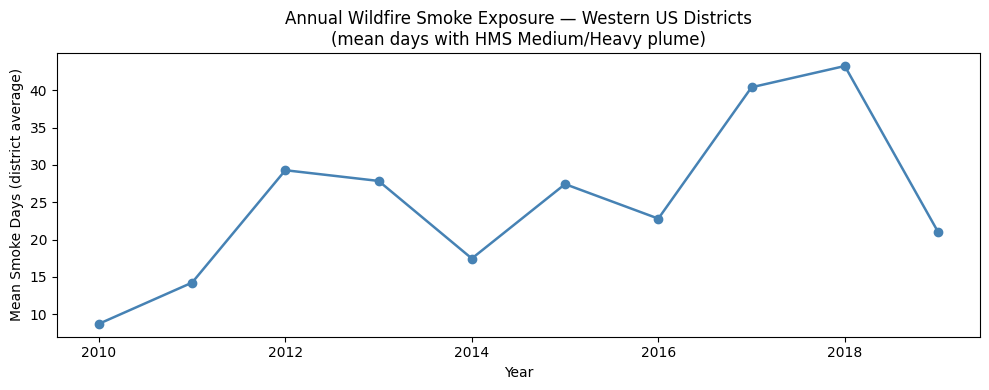

2018 spike expected from Camp Fire and other major fires


In [3]:
annual = smoke.groupby("year")["smoke_days"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual["year"], annual["smoke_days"], marker="o", lw=1.8, c="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Smoke Days (district average)")
ax.set_title("Annual Wildfire Smoke Exposure — Western US Districts\n(mean days with HMS Medium/Heavy plume)")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_smoke_days_trend.png", bbox_inches="tight")
plt.show()
print("2018 spike expected from Camp Fire and other major fires")

## Exclusion restriction discussion

**Threats to exclusion:**
1. School closures during extreme smoke events (direct effect on scores not through PM2.5)
2. Economic disruption from wildfires (evacuations, property damage affect families)
3. Teacher absenteeism

**Mitigations:**
- Use smoke_days as instrument (cumulative exposure), not acute extreme events
- Robustness: drop districts in counties with major fire events in that year
- Robustness: drop 2018 (Camp Fire) entirely